***Exploratory Data Analysis***

***Dataset:*** Sales Forecasting Dataset(Kaggle)

Perform structured exploratory analysis to uncover insights and prepare data for forecasting.


**1. Ask Meaningful Questions Before Analysis**

- Are there seasonal patterns in sales over time?

- Which product categories generate the highest revenue?

- Do customer segments significantly differ in purchasing behavior?

- Are there regional differences in sales performance?

- Are there extreme sales values affecting overall metrics?

In [92]:
# Import the required Liabraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

*Load the data file*

In [95]:
df = pd.read_csv('train.csv')
df.head(5)
# Look at the top 5 records of data

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12/06/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680


Check the various attributes of data like shape (rows and cols), Columns, datatypes

In [35]:
df.shape

(9800, 18)

In [37]:
df.columns.values

array(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City',
       'State', 'Postal Code', 'Region', 'Product ID', 'Category',
       'Sub-Category', 'Product Name', 'Sales'], dtype=object)

In [39]:
# Checking the datatypes of all the columns
df.dtypes

Row ID             int64
Order ID          object
Order Date        object
Ship Date         object
Ship Mode         object
Customer ID       object
Customer Name     object
Segment           object
Country           object
City              object
State             object
Postal Code      float64
Region            object
Product ID        object
Category          object
Sub-Category      object
Product Name      object
Sales            float64
dtype: object

In [41]:
# Check the descriptive statistics of the numeric variables
df.describe()

,Row ID,Postal Code,Sales
count,9800.000000,9789.000000,9800.000000
mean,4900.500000,55273.322403,230.769059
std,2829.160653,32041.223413,626.651875
min,1.000000,1040.000000,0.444000
25%,2450.750000,23223.000000,17.248000
50%,4900.500000,58103.000000,54.490000
75%,7350.250000,90008.000000,210.605000
max,9800.000000,99301.000000,22638.480000


The Sales column is highly right-skewed, as the mean (230.77) is much higher than the median (54.49)

The dataset contains missing values in the Postal Code column (11 missing entries)

Order Date and Ship Date are stored as object type instead of datetime

In [54]:
# Converting date columns to datetime format (DD/MM/YYYY)
df['Order Date'] = pd.to_datetime(df['Order Date'], dayfirst=True)
df['Ship Date'] = pd.to_datetime(df['Ship Date'], dayfirst=True)

In [52]:
df[['Order Date','Ship Date']].head()
df.dtypes

Row ID                    int64
Order ID                 object
Order Date       datetime64[ns]
Ship Date        datetime64[ns]
Ship Mode                object
Customer ID              object
Customer Name            object
Segment                  object
Country                  object
City                     object
State                    object
Postal Code             float64
Region                   object
Product ID               object
Category                 object
Sub-Category             object
Product Name             object
Sales                   float64
dtype: object

In [56]:
# Extract year from Order Date
df['Year'] = df['Order Date'].dt.year

# Extract month number
df['Month'] = df['Order Date'].dt.month

# Extract month name (for better visualization)
df['Month_Name'] = df['Order Date'].dt.month_name()

# Extract day of week
df['Day_of_Week'] = df['Order Date'].dt.day_name()


In [58]:
df.isnull().sum()

Row ID            0
Order ID          0
Order Date        0
Ship Date         0
Ship Mode         0
Customer ID       0
Customer Name     0
Segment           0
Country           0
City              0
State             0
Postal Code      11
Region            0
Product ID        0
Category          0
Sub-Category      0
Product Name      0
Sales             0
Year              0
Month             0
Month_Name        0
Day_of_Week       0
dtype: int64

In [61]:
df.duplicated().sum()

0

The dataset contains minimal missing values and no significant duplicate records.

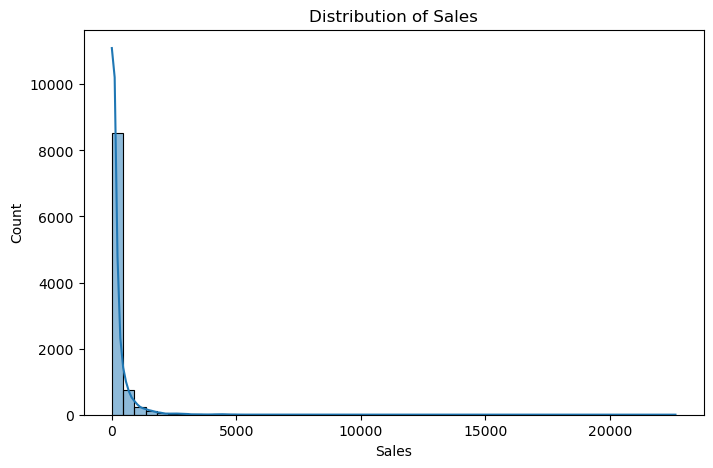

In [63]:
plt.figure(figsize=(8,5))
sns.histplot(df['Sales'], bins=50, kde=True)
plt.title("Distribution of Sales")
plt.show()

In [141]:
# Skewness
df['Sales'].skew()

12.983482865034619

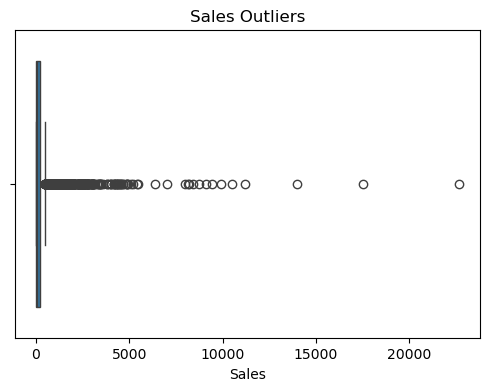

In [65]:
plt.figure(figsize=(6,4))
sns.boxplot(x=df['Sales'])
plt.title("Sales Outliers")
plt.show()

Sales distribution is right-skewed

Presence of high-value outliers

Sales not normally distributed.

In [144]:
# Apply log transformation
df['Log_Sales'] = np.log1p(df['Sales'])

# Check skewness after transformation
df['Log_Sales'].skew()

0.2810852775024328

Log transformation reduces skewness significantly.
Recommended for modeling.

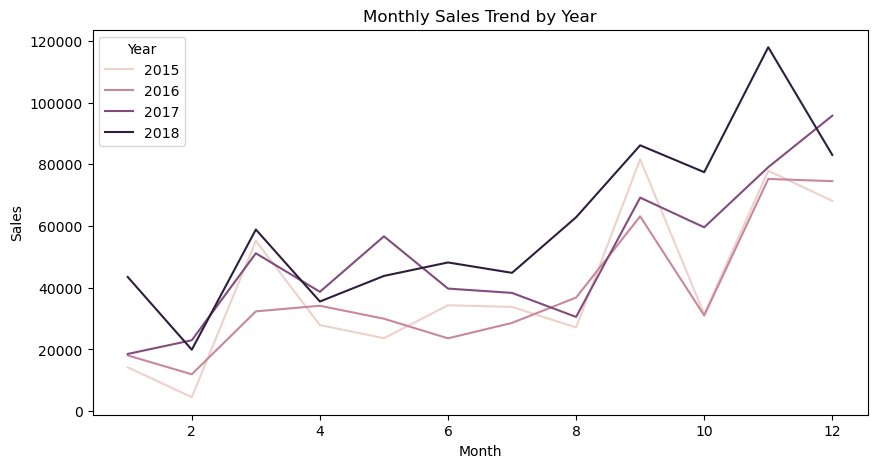

In [69]:
monthly_sales = df.groupby(['Year','Month'])['Sales'].sum().reset_index()

plt.figure(figsize=(10,5))
sns.lineplot(data=monthly_sales, x='Month', y='Sales', hue='Year')
plt.title("Monthly Sales Trend by Year")
plt.show()

Clear seasonal patterns observed. Certain months (Oct-Dec) consistently show higher sales, indicating time-based demand behavior.

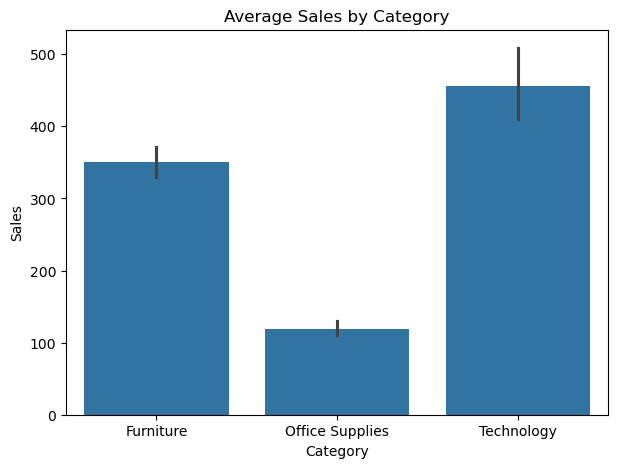

In [71]:
plt.figure(figsize=(7,5))
sns.barplot(data=df, x='Category', y='Sales', estimator=np.mean)
plt.title("Average Sales by Category")
plt.show()

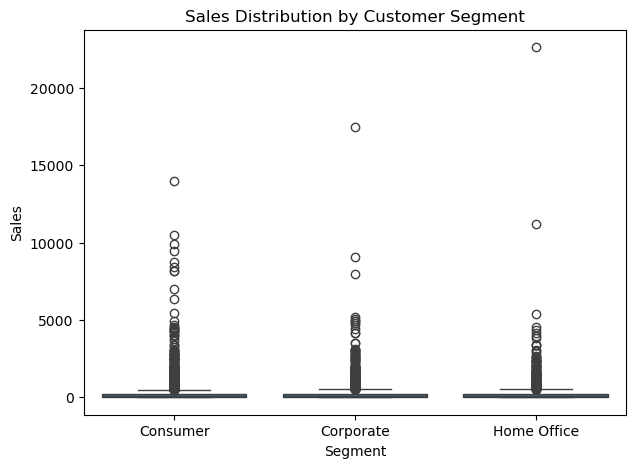

In [73]:
plt.figure(figsize=(7,5))
sns.boxplot(data=df, x='Segment', y='Sales')
plt.title("Sales Distribution by Customer Segment")
plt.show()

Consumer segment contributes most transactions

Technology category often shows higher average sales

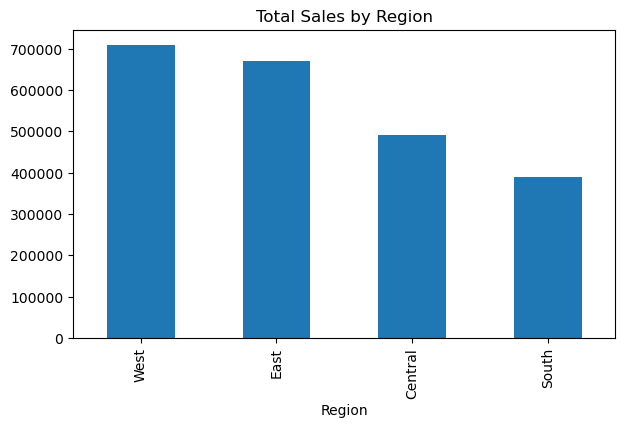

In [76]:
region_sales = df.groupby('Region')['Sales'].sum().sort_values(ascending=False)

region_sales.plot(kind='bar', figsize=(7,4), title="Total Sales by Region")
plt.show()

Sales performance varies across regions, indicating geographic revenue concentration.

***Hypothesis Testing***

In [121]:
#Hypothesis: Sales Differ Across Customer Segments
#H₀: Mean sales are equal across segments
#H₁: At least one segment differs

consumer = df[df['Segment']=='Consumer']['Sales']
corporate = df[df['Segment']=='Corporate']['Sales']
home_office = df[df['Segment']=='Home Office']['Sales']

# Perform one-way ANOVA test
from scipy import stats

anova_result = stats.f_oneway(consumer,
                              corporate,
                              home_office)

# Display ANOVA results
anova_result

F_onewayResult(statistic=0.5874032714436911, pvalue=0.5557881652680301)

In [119]:
# Perform Kruskal-Wallis test (does not assume normality)

kruskal_result = stats.kruskal(consumer,
                               corporate,
                               home_office)

# Display result
kruskal_result

KruskalResult(statistic=0.43937522529886164, pvalue=0.8027695338448759)

**Based on the Result:**

ANOVA p-value = 0.5558

Kruskal p-value = 0.8028

Both > 0.05

Therefore:
There is no statistically significant difference in sales across customer segments.

Both parametric (ANOVA) and non-parametric (Kruskal-Wallis) tests indicate no statistically significant difference in sales across customer segments. This suggests that customer segment does not significantly influence transaction-level sales values.

In [137]:
# Calculate 99th percentile threshold
threshold_99 = df['Sales'].quantile(0.99)

# Filter top 1% transactions
high_sales = df[df['Sales'] > threshold_99]

# Check shape
high_sales.shape


(98, 18)

In [148]:
# Revenue contribution of top 1%
(high_sales['Sales'].sum() / df['Sales'].sum()) * 100

19.758356946400156

Top 1% of transactions contribute ~19.76% of total revenue.

Minor missing values (Postal Code).
Heavy outlier influence and non-normal distribution affect statistical assumptions.

***Conclusion***

This EDA helped understand how sales are distributed, how revenue is concentrated, and how trends change over time. It identified key factors like category and region that affect performance and used statistical testing to validate findings. These insights create a strong base for forecasting and better business decisions.